## CUSTODIAN STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

ekocorp=pd.read_csv('../stock_data/ekocorp.csv') ## so it can be small letter. This is cool.
ekocorp=ekocorp.drop(columns=['high_price','low_price'])
ekocorp.rename(columns={'trade_date':'date'},inplace=True)
ekocorp['date']=pd.to_datetime(ekocorp['date'])
ekocorp['month']=ekocorp['date'].dt.month
ekocorp['quarter']=ekocorp['date'].dt.quarter
ekocorp['year']=ekocorp['date'].dt.year

ekocorp

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42830,EKOCORP,2017-01-03,3.21,3.21,0.0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43390,EKOCORP,2017-01-04,3.21,3.21,0.0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43500,EKOCORP,2017-01-05,3.21,3.21,0.0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43610,EKOCORP,2017-01-06,3.21,3.21,0.0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43700,EKOCORP,2017-01-09,3.21,3.21,0.0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2256,298052,EKOCORP,2026-07-13,5.80,5.80,NaN,2026-07-13T15:10:02.995074+00:00,7,3,2026
2257,298490,EKOCORP,2026-07-14,5.80,5.80,NaN,2026-07-14T15:10:03.094441+00:00,7,3,2026
2258,298928,EKOCORP,2026-07-15,5.80,5.80,NaN,2026-07-15T15:10:03.078609+00:00,7,3,2026
2259,299366,EKOCORP,2026-07-16,5.80,5.80,NaN,2026-07-16T15:10:03.113936+00:00,7,3,2026


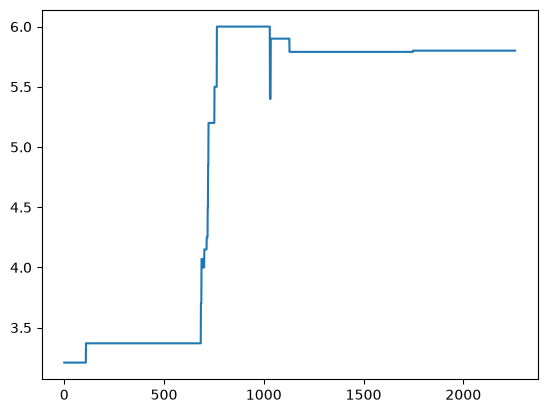

In [2]:
import matplotlib.pyplot as plt

plt.plot(ekocorp['close_price'])
plt.show()

In [3]:
ekocorp_end_month_df = (
    ekocorp
    .sort_values("date")
    .groupby(ekocorp["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

ekocorp_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45400,EKOCORP,2017-01-31,3.21,3.21,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47222,EKOCORP,2017-02-28,3.21,3.21,0.0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49338,EKOCORP,2017-03-31,3.21,3.21,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51165,EKOCORP,2017-04-28,3.21,3.21,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53088,EKOCORP,2017-05-31,3.21,3.21,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35290,EKOCORP,2026-03-31,5.80,5.80,0.0,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281116,EKOCORP,2026-04-30,5.80,5.80,NaN,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284182,EKOCORP,2026-05-29,5.80,5.80,NaN,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294110,EKOCORP,2026-06-30,5.80,5.80,NaN,2026-06-30T15:10:03.08168+00:00,6,2,2026


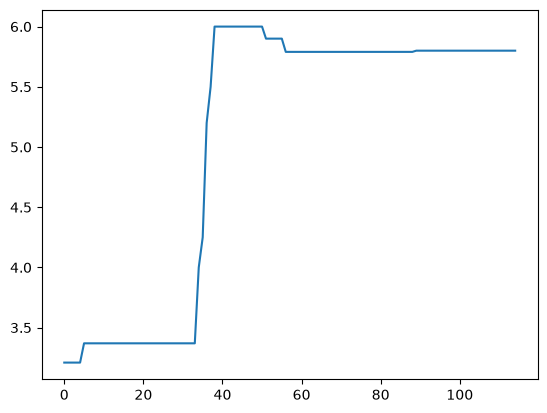

In [4]:
plt.plot(ekocorp_end_month_df['close_price'])
plt.show()

In [5]:
ekocorp_end_month_df['returns']=ekocorp_end_month_df['close_price'].pct_change()*100
ekocorp_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45400,EKOCORP,2017-01-31,3.21,3.21,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47222,EKOCORP,2017-02-28,3.21,3.21,0.0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.0
2,49338,EKOCORP,2017-03-31,3.21,3.21,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.0
3,51165,EKOCORP,2017-04-28,3.21,3.21,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.0
4,53088,EKOCORP,2017-05-31,3.21,3.21,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.0
...,...,...,...,...,...,...,...,...,...,...,...
110,35290,EKOCORP,2026-03-31,5.80,5.80,0.0,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.0
111,281116,EKOCORP,2026-04-30,5.80,5.80,NaN,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.0
112,284182,EKOCORP,2026-05-29,5.80,5.80,NaN,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.0
113,294110,EKOCORP,2026-06-30,5.80,5.80,NaN,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.0


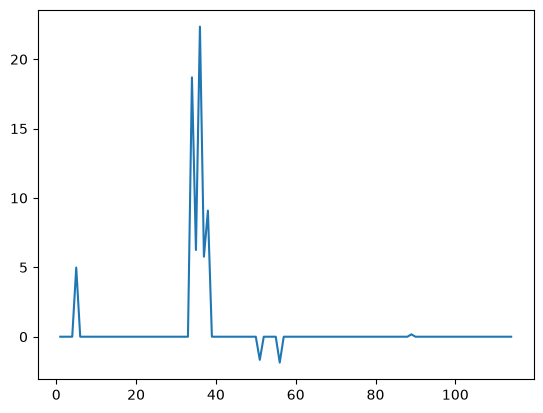

In [6]:
plt.plot(ekocorp_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(ekocorp_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-3.257696810421566), np.float64(0.016878623165345476), 6, 107, {'1%': np.float64(-3.492995948509562), '5%': np.float64(-2.888954648057252), '10%': np.float64(-2.58139291903223)}, np.float64(431.55036920222057))
stationary


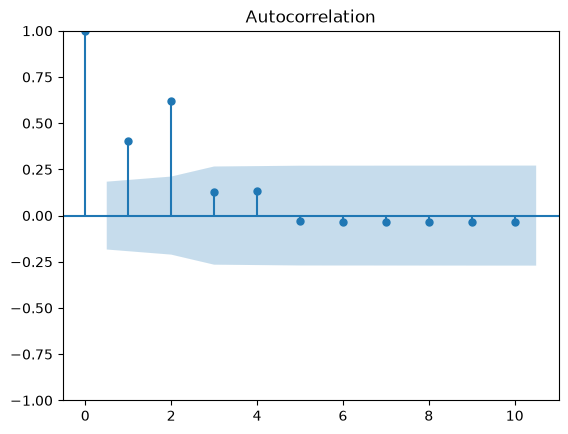

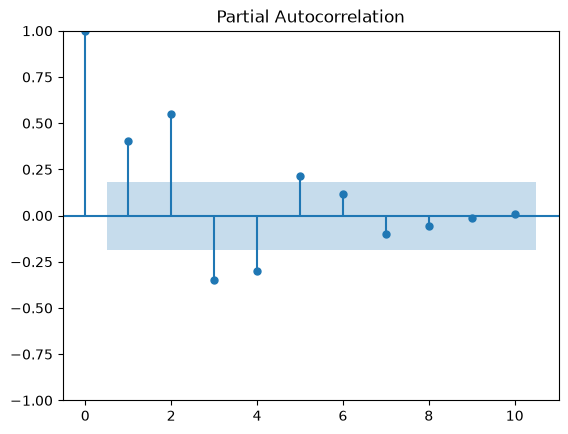

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ekocorp_end_month_df['returns'].dropna(), lags=10)
plot_pacf(ekocorp_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ekocorp_end_month_df['close_price'][:-10]
test=ekocorp_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -4.264376619167764e+31]
[0, 0, 0, 0, 0, 1, -1.2730268486328223e+31]
[0, 0, 0, 0, 0, 2, -4.3140319271414344e+30]
[0, 0, 0, 0, 1, 0, 1.0]
[0, 0, 0, 0, 1, 1, -5.806812714866569e+22]
[0, 0, 0, 0, 1, 2, -8.767211000443732e+22]
[0, 0, 0, 0, 2, 0, -1.0141204802054638e+26]
[0, 0, 0, 0, 2, 1, -1.356111503807518e+29]
[0, 0, 0, 0, 2, 2, -1.3953675507324132e+29]
[0, 0, 0, 1, 0, 0, -1.254673925026744e+28]
[0, 0, 0, 1, 0, 1, -1.3249044921120523e+28]
[0, 0, 0, 1, 0, 2, -1.310124107211241e+28]
[0, 0, 0, 1, 1, 0, -5.449187740561841e+22]
[0, 0, 0, 1, 1, 1, -1.891021729489393e+25]
[0, 0, 0, 1, 1, 2, -7.471346499442437e+24]
[0, 0, 0, 1, 2, 0, -3.8370943491170217e+25]
[0, 0, 0, 1, 2, 1, -1.387816942674401e+29]
[0, 0, 0, 1, 2, 2, -1.2849510427951733e+29]
[0, 0, 0, 2, 0, 0, -1.326436964354698e+28]
[0, 0, 0, 2, 0, 1, -2.0212871955671105e+28]
[0, 0, 0, 2, 0, 2, -1.7620209824476222e+28]
[0, 0, 0, 2, 1, 0, -6.170497062451812e+22]
[0, 0, 0, 2, 1, 1, -1.3118648257174843e+24]
[0, 0, 0, 2, 1, 2, -

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
179,0,2,0,1,2,2,-6.542814e+31
188,0,2,0,2,2,2,-6.542814e+31
0,0,0,0,0,0,0,-4.264377e+31
27,0,0,1,0,0,0,-3.928874e+31
54,0,0,2,0,0,0,-3.695736e+31
...,...,...,...,...,...,...,...
675,2,2,1,0,0,0,1.000000e+00
648,2,2,0,0,0,0,1.000000e+00
324,1,1,0,0,0,0,1.000000e+00
333,1,1,0,1,0,0,1.000000e+00


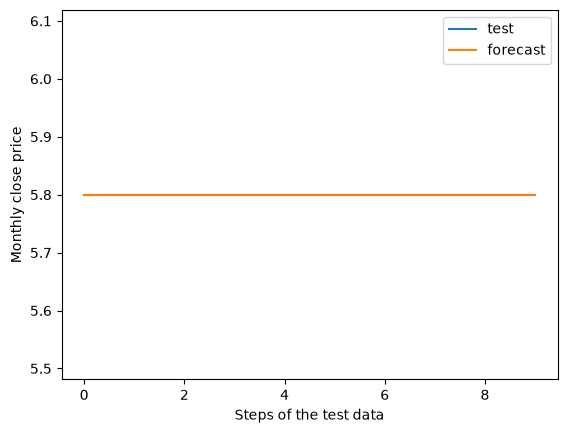

r2_score:  1.0
rmse:  0.0
description:  count    115.000000
mean       5.061739
std        1.142366
min        3.210000
25%        3.370000
50%        5.790000
75%        5.800000
max        6.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=ekocorp_end_month_df['close_price'][:-10]
y_test=ekocorp_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', ekocorp_end_month_df.close_price.describe())

The data itself is too static. We cant work with this